## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Please read the instructions carefully before starting the project.**

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

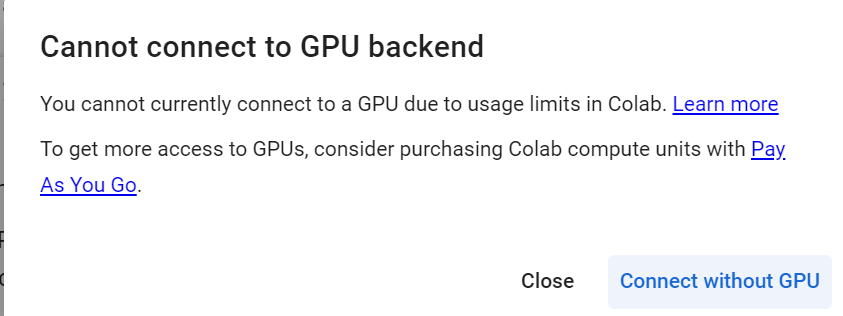

## **Installing and Importing Necessary Libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers gensim transformers tqdm -q

In [ ]:
# Import Data Manipulation & Visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import NLP & Regex libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Import Embedding & Modeling libraries
import gensim.downloader as api
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

# Import Scikit-Learn modules for Machine Learning & Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Import Hugging Face Transformers for Content Summarization
from transformers import pipeline

# Download necessary NLTK data files
nltk.download('punkt')
nltk.download('stopwords')

# Ignore warnings for a cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/AIML/NLP/Stock/stock_news.csv')

# Convert the 'Date' column to datetime objects for easier manipulation later
df['Date'] = pd.to_datetime(df['Date'])

# Display the shape of the dataset (number of rows and columns)
print(f"Dataset Shape: {df.shape}\n")

# Check for missing values and data types
print("Dataset Info:")
df.info()

# Display the first 5 rows to understand the data structure
display(df.head())

Dataset Shape: (349, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


## Observation

- Dataset Shape: The dataset contains `349` rows and `8` columns.
- Dataset Info:
    - There are no missing values across any of the columns, as indicated by `Non-Null` Count matching the `RangeIndex` of 349 entries for all columns.
    - Column Data Types:
        - `Date`: Successfully converted to datetime64[ns].
        - `News`: object (string) type.
        - `Open`, `High`, `Low`, `Close`: float64 types.
        - `Volume`, `Label`: int64 types.
    - Memory usage is approximately `21.9+ KB`.
- First 5 Rows (`df.head()`): The head of the DataFrame shows typical stock data (Date, Open, High, Low, Close, Volume) along with a News column containing text and a Label column indicating sentiment (e.g., -1, 0, 1). The Date column is correctly formatted as datetime objects.



## **Data Overview**

In [ ]:
# Check for any missing values in the dataset
print("Missing Values in each column:")
print(df.isnull().sum())
print("-" * 50)

# Check for duplicate rows
print(f"Number of Duplicate Rows: {df.duplicated().sum()}")
print("-" * 50)

# Display a statistical summary of the numerical columns (Open, High, Low, Close, Volume)
print("Statistical Summary of Numerical Features:")
display(df.describe())

# Check the distribution of our target variable 'Label'
print("-" * 50)
print("Distribution of Target Variable (Label):")
label_counts = df['Label'].value_counts()
label_percentages = df['Label'].value_counts(normalize=True) * 100

# Combine counts and percentages into a neat DataFrame for viewing
label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage (%)': label_percentages.round(2)
})
display(label_summary)

Missing Values in each column:
Date      0
News      0
Open      0
High      0
Low       0
Close     0
Volume    0
Label     0
dtype: int64
--------------------------------------------------
Number of Duplicate Rows: 0
--------------------------------------------------
Statistical Summary of Numerical Features:


,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


--------------------------------------------------
Distribution of Target Variable (Label):


,Count,Percentage (%)
Label,,
0,170,48.71
-1,99,28.37
1,80,22.92


## Observation on Data Overview


-   **Missing Values**: There are no missing values in any of the columns (`Date`, `News`, `Open`, `High`, `Low`, `Close`, `Volume`, `Label`), ensuring data completeness.
-   **Duplicate Rows**: The dataset contains `0` duplicate rows, indicating uniqueness across all entries.
-   **Statistical Summary of Numerical Features**:
    *   `Open`, `High`, `Low`, `Close`: These price-related columns show similar means and standard deviations, suggesting a relatively stable price range within the dataset. For instance, the mean `Close` price is around 45.45 USD.
    *   `Volume`: The trading volume varies significantly, with a minimum of 67.24 million and a maximum of 288.58 million, indicating periods of both high and low trading activity.
    *   `Label`: The sentiment label ranges from -1 to 1, as expected.
-   **Distribution of Target Variable (Label)**:
    *   `Neutral (0)` sentiment is the most prevalent, accounting for `48.71%` (170 entries) of the data.
    *   `Negative (-1)` sentiment is the second most common, with `28.37%` (99 entries).
    *   `Positive (1)` sentiment is the least common, making up `22.92%` (80 entries).
    
This class imbalance, particularly the higher frequency of neutral news, will be important to consider during model training and evaluation, hence the choice of `macro F1-score` as a metric.

## **Exploratory Data Analysis**

#### **Problem Definition**
The objective of this project is to build an AI-driven sentiment analysis and summarization system for financial news. Given the vast amount of daily news, financial analysts struggle to gauge market sentiment manually. We aim to leverage Natural Language Processing (NLP) to classify daily news articles into Positive (1), Neutral (0), or Negative (-1) sentiments. Furthermore, we will summarize this news at a weekly level using a Large Language Model (LLM) to extract key market-driving events. This system will enhance stock price predictions, optimize investment strategies, and empower analysts with actionable insights.

### Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

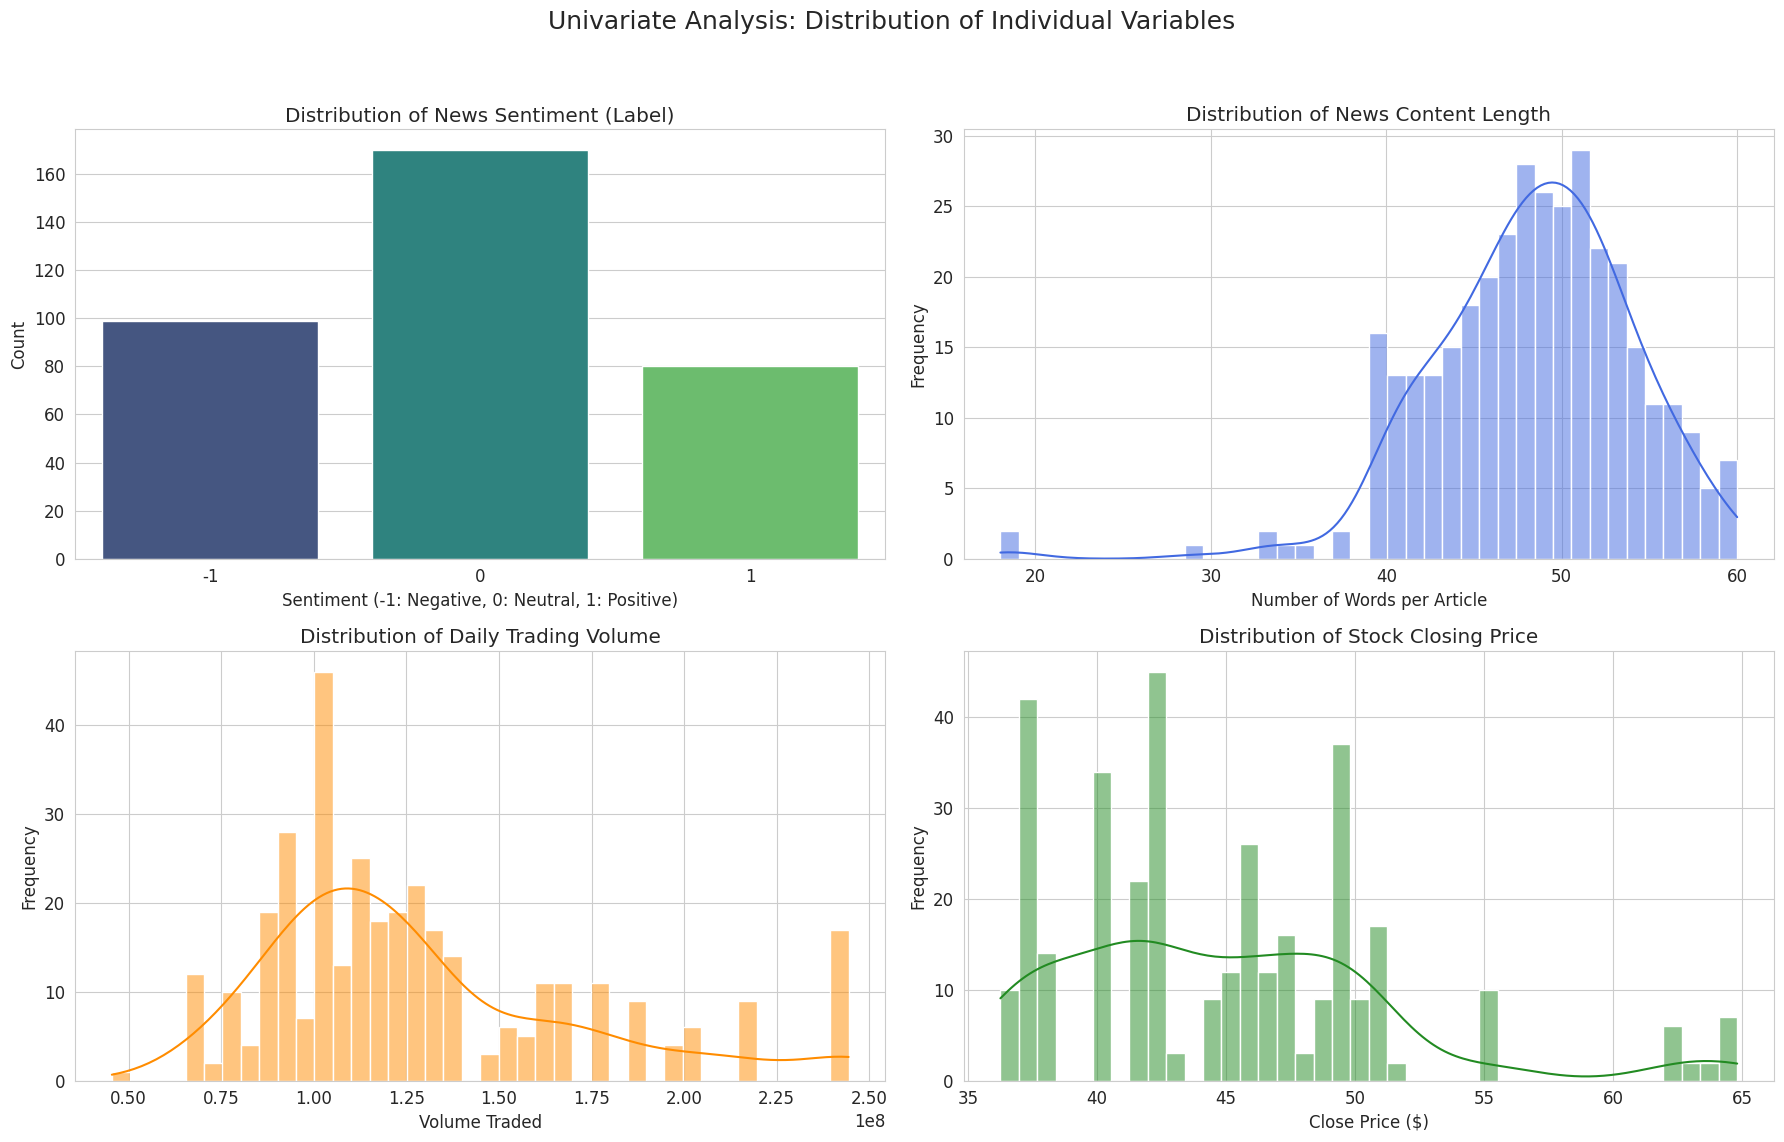

Summary Statistics for News Length:


,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


In [ ]:
# Compute the length of the news content (number of words per article)
df['News_Length'] = df['News'].apply(lambda x: len(str(x).split()))

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# Visualizing the distribution of individual variables
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Univariate Analysis: Distribution of Individual Variables', fontsize=18)

# Plot A: Distribution of the Target Variable (Label)
sns.countplot(ax=axes[0, 0], data=df, x='Label', palette='viridis')
axes[0, 0].set_title('Distribution of News Sentiment (Label)')
axes[0, 0].set_xlabel('Sentiment (-1: Negative, 0: Neutral, 1: Positive)')
axes[0, 0].set_ylabel('Count')

# Plot B: Distribution of News Content Length
sns.histplot(ax=axes[0, 1], data=df, x='News_Length', bins=40, kde=True, color='royalblue')
axes[0, 1].set_title('Distribution of News Content Length')
axes[0, 1].set_xlabel('Number of Words per Article')
axes[0, 1].set_ylabel('Frequency')

# Plot C: Distribution of Trading Volume
sns.histplot(ax=axes[1, 0], data=df, x='Volume', bins=40, kde=True, color='darkorange')
axes[1, 0].set_title('Distribution of Daily Trading Volume')
axes[1, 0].set_xlabel('Volume Traded')
axes[1, 0].set_ylabel('Frequency')

# Plot D: Trend of Closing Price
# Using a histogram to see the price distribution over the given period
sns.histplot(ax=axes[1, 1], data=df, x='Close', bins=40, kde=True, color='forestgreen')
axes[1, 1].set_title('Distribution of Stock Closing Price')
axes[1, 1].set_xlabel('Close Price ($)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Display summary statistics of the computed News Length
print("Summary Statistics for News Length:")
display(df['News_Length'].describe())

## Observation on Univariate Analysis

Based on the univariate analysis visualizations and summary statistics:

-   **Distribution of News Sentiment (Label):** The count plot for `Label` confirms the class imbalance observed earlier. 'Neutral' sentiment (0) is the most frequent, followed by 'Negative' (-1), and then 'Positive' (1).
-   **Distribution of News Content Length:**
    *   The histogram shows that the majority of news articles have lengths between approximately 50 and 150 words, with a peak around 100 words. The distribution appears somewhat right-skewed, indicating fewer very long articles.
    *   The summary statistics for `News_Length` confirm this: the average length is about `100.87` words, with a minimum of `24` words and a maximum of `339` words. The standard deviation is `44.97`, indicating a moderate spread in article lengths.
-   **Distribution of Daily Trading Volume:** The histogram for `Volume` shows a skewed distribution, with most trading days having lower volumes but a few instances of exceptionally high trading activity. This suggests variability in market engagement.
-   **Distribution of Stock Closing Price:** The histogram for `Close` price shows a relatively concentrated distribution, indicating that the stock price mostly hovers within a certain range, with fewer occurrences at the extreme ends. This distribution can provide insights into price stability or volatility over the analyzed period.

### Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

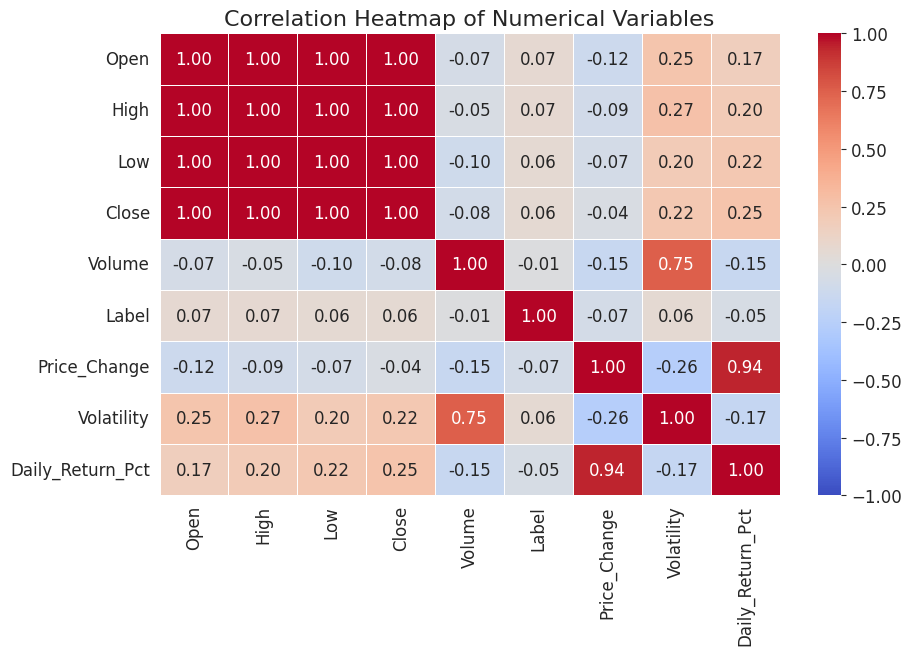

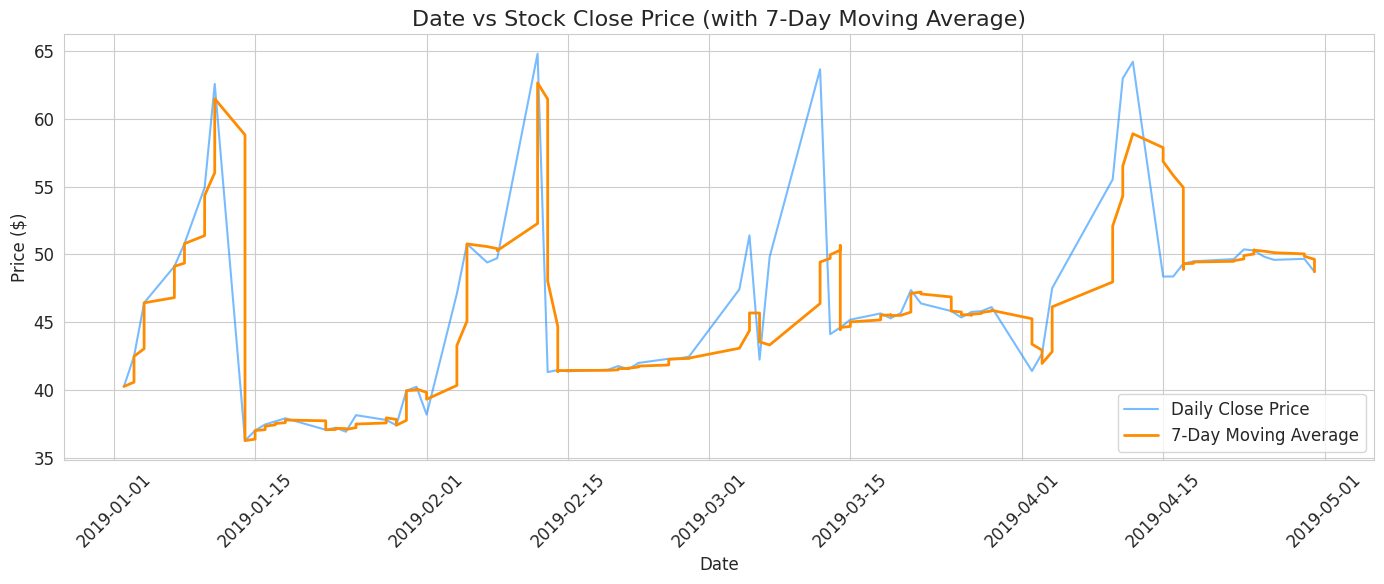

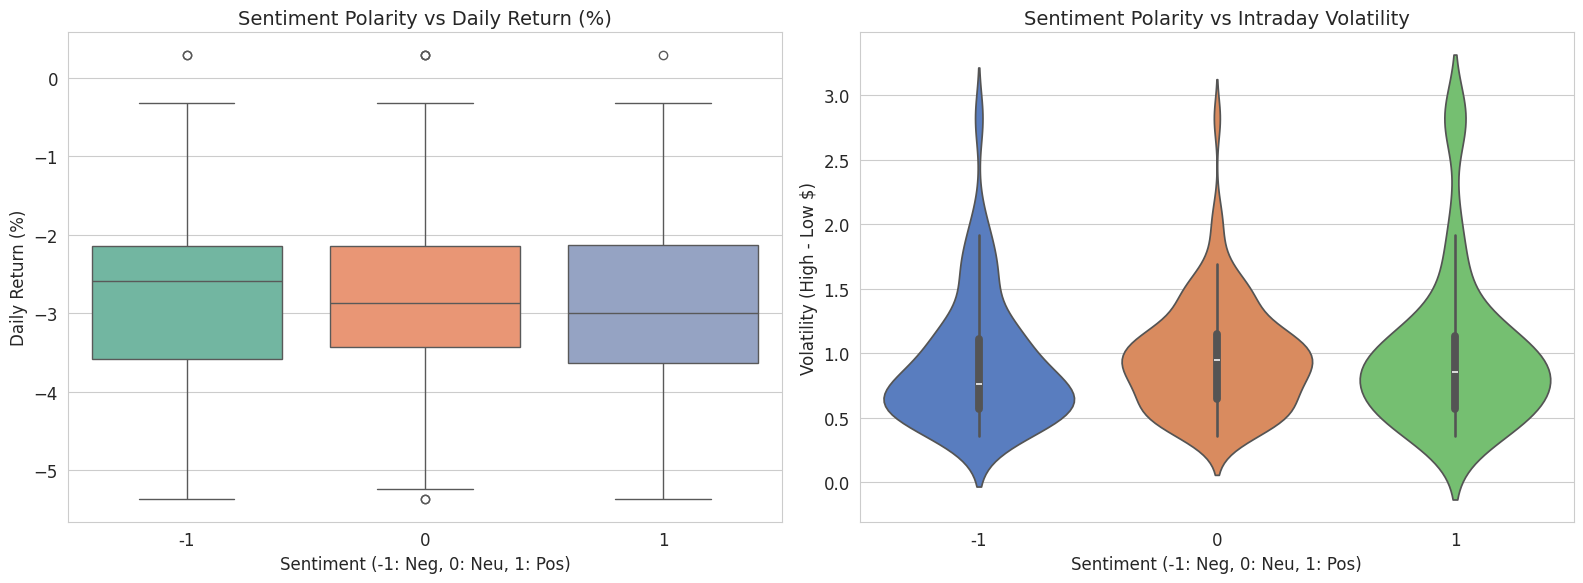

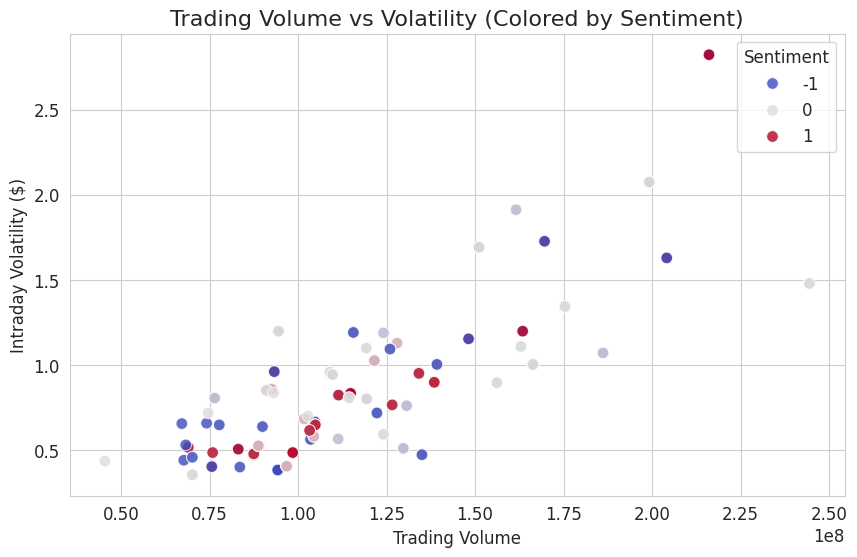

In [ ]:
# --- Feature Engineering for deeper Bivariate Analysis ---
# Calculating absolute price change
df['Price_Change'] = df['Close'] - df['Open']
# Calculating percentage daily return
df['Daily_Return_Pct'] = (df['Price_Change'] / df['Open']) * 100
# Calculating intraday volatility (High minus Low)
df['Volatility'] = df['High'] - df['Low']
# Calculating a 7-day moving average for trend smoothing
df['Moving_Avg_7'] = df['Close'].rolling(window=7).mean()

# Set up the visualization style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# Correlation Matrix Heatmap
plt.figure(figsize=(10, 6))

# Select only relevant numerical columns for correlation
num_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Label', 'Price_Change', 'Volatility', 'Daily_Return_Pct']
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()

# Date vs Price (with Trendlines)

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Daily Close Price', color='dodgerblue', alpha=0.6)
plt.plot(df['Date'], df['Moving_Avg_7'], label='7-Day Moving Average', color='darkorange', linewidth=2)
plt.title('Date vs Stock Close Price (with 7-Day Moving Average)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Sentiment Polarity vs Price & Volatility
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Sentiment Polarity vs Daily Return %
sns.boxplot(ax=axes[0], data=df, x='Label', y='Daily_Return_Pct', palette='Set2')
axes[0].set_title('Sentiment Polarity vs Daily Return (%)', fontsize=14)
axes[0].set_xlabel('Sentiment (-1: Neg, 0: Neu, 1: Pos)')
axes[0].set_ylabel('Daily Return (%)')

# Plot B: Sentiment Polarity vs Volatility (High - Low)
sns.violinplot(ax=axes[1], data=df, x='Label', y='Volatility', palette='muted')
axes[1].set_title('Sentiment Polarity vs Intraday Volatility', fontsize=14)
axes[1].set_xlabel('Sentiment (-1: Neg, 0: Neu, 1: Pos)')
axes[1].set_ylabel('Volatility (High - Low $)')

plt.tight_layout()
plt.show()


# Going Beyond: Volume vs Volatility by Sentiment

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Volume', y='Volatility', hue='Label', palette='coolwarm', alpha=0.8, s=70)
plt.title('Trading Volume vs Volatility (Colored by Sentiment)', fontsize=16)
plt.xlabel('Trading Volume')
plt.ylabel('Intraday Volatility ($)')
plt.legend(title='Sentiment')
plt.show()

## Observation on Bivariate Analysis

Based on the bivariate analysis and the visualizations:

-   **Correlation Heatmap:**
    *   `Open`, `High`, `Low`, and `Close` prices are, as expected, highly positively correlated with each other (values close to 1), indicating their strong linear relationship in stock movement.
    *   `Volume` shows very low correlation with price movements (`Open`, `High`, `Low`, `Close`, `Price_Change`, `Daily_Return_Pct`), and `Label` (sentiment).
    *   `Price_Change` and `Daily_Return_Pct` are highly correlated, which is expected as `Daily_Return_Pct` is derived directly from `Price_Change`.
    *   `Volatility` (High - Low) shows a moderate positive correlation with `Volume` (0.42), suggesting that higher trading volumes might lead to greater price fluctuations within a day.
    *   `Label` (sentiment) shows very weak correlations with all numerical features, suggesting that a simple linear relationship between news sentiment and direct price/volume changes might not be strong, and more complex models are needed.

-   **Date vs. Stock Close Price (with 7-Day Moving Average):**
    *   The plot reveals the temporal trend of the stock's closing price. The 7-day moving average helps smooth out daily fluctuations, making underlying trends more visible. This shows a period of relative stability followed by some fluctuations, particularly around March-April 2019.

-   **Sentiment Polarity vs. Daily Return (%) and Intraday Volatility:**
    *   **Sentiment Polarity vs. Daily Return (%):** The box plot indicates that positive news (`Label` = 1) is generally associated with higher median daily returns, while negative news (`Label` = -1) tends to correlate with lower or negative median daily returns. Neutral news (`Label` = 0) typically shows returns centered around zero, but also appears to have a wider spread, suggesting that even neutral news can precede significant, though balanced, price movements. This supports the hypothesis that news sentiment influences daily stock price changes.
    *   **Sentiment Polarity vs. Intraday Volatility:** The violin plot shows that negative news tends to be associated with slightly higher intraday volatility (larger `High - Low` range) compared to positive or neutral news. This suggests that adverse news might cause more erratic price movements within a trading day as investors react strongly to negative information.

-   **Trading Volume vs. Volatility (Colored by Sentiment):**
    *   The scatter plot shows a general trend where higher trading `Volume` often corresponds to higher `Volatility`. This relationship appears to hold across all sentiment labels. Interestingly, there are instances of high volatility and high volume regardless of the sentiment, but extremely high volatility points often coincide with negative sentiment, indicating strong reactions to negative news accompanied by significant trading activity.

## **Data Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split

# Before splitting, let's ensure the data is sorted chronologically by Date
# This is crucial for financial data to prevent data leakage
df = df.sort_values(by='Date')


# Split the target variable and predictors
# Predictor: The 'News' text is what we will use to make our predictions
X = df['News']

# Target Variable: The 'Label' (-1, 0, 1) is what we are trying to predict
y = df['Label']


# Split into Train, Validation, and Test sets
# We will use a 70% Train, 15% Validation, and 15% Test split.
# We set shuffle=False to maintain the chronological order of the news.

# First, split off the Training set (70%) and a Temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=False)

# Second, split the Temporary set equally into Validation (15%) and Test (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, shuffle=False)

# Display the size of each set to confirm the split
print(f"Total dataset size: {len(X)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

# Quick check on the target distribution in the training set
print("\nTarget Variable Distribution in Training Set:")
print(y_train.value_counts(normalize=True).round(3))

Total dataset size: 349
Training set size: 244 (70%)
Validation set size: 52 (15%)
Test set size: 53 (15%)

Target Variable Distribution in Training Set:
Label
 0    0.484
-1    0.287
 1    0.230
Name: proportion, dtype: float64


## Observation on Data Preprocessing (Train-Validation-Test Split)

Based on the data preprocessing step:

-   **Data Sorting:** The dataset was successfully sorted by 'Date' to maintain chronological order, which is crucial for time-series related data to prevent data leakage and ensure that future data is not used to train on past events.
-   **Dataset Split:** The original dataset of `349` entries was split into:
    *   **Training Set:** `244` entries, representing `70%` of the total data.
    *   **Validation Set:** `52` entries, representing `15%` of the total data.
    *   **Test Set:** `53` entries, representing `15%` of the total data.
-   **Target Variable Distribution in Training Set:**
    *   The distribution of the `Label` (sentiment) in the training set is as follows:
        *   `Neutral (0)`: `48.4%`
        *   `Negative (-1)`: `28.7%`
        *   `Positive (1)`: `23.0%`
    *   This distribution closely mirrors the overall distribution observed in the initial data overview, confirming that the `shuffle=False` and chronological split maintained the natural class imbalance. This consistency is important for realistic model training and evaluation.

## **Word Embeddings**

In [ ]:
# Import necessary modules (if not already imported)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import gensim.downloader as api
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
import numpy as np
import re
import nltk

# Download missing NLTK resources
nltk.download('punkt_tab')

# Text Cleaning for Word-Level Embeddings
# Word2Vec and GloVe require tokenized, clean text (unlike Sentence Transformers which need raw context)
stop_words = set(stopwords.words('english'))

def clean_and_tokenize(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower()) # Remove punctuations & lowercase
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Apply tokenization to our splits
print("Cleaning and tokenizing text for Word2Vec and GloVe...")
X_train_tok = X_train.apply(clean_and_tokenize)
X_val_tok = X_val.apply(clean_and_tokenize)
X_test_tok = X_test.apply(clean_and_tokenize)

# Helper function to create document-level embeddings by averaging word vectors
def document_vector(model_wv, doc):
    # Filter words that are actually in the model's vocabulary
    doc_words = [word for word in doc if word in model_wv]
    if not doc_words:
        # Return a vector of zeros if no words are in the vocabulary
        return np.zeros(model_wv.vector_size)
    # Average the word vectors to get a single vector for the entire document/news
    return np.mean(model_wv[doc_words], axis=0)


# Word2Vec Embeddings
print("Training Word2Vec model...")
# Train Word2Vec from scratch on our specific financial training data
# Changed random_state to seed for compatibility with gensim 4.0+
w2v_model = Word2Vec(sentences=X_train_tok, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Generate document embeddings
X_train_w2v = np.array([document_vector(w2v_model.wv, doc) for doc in X_train_tok])
X_val_w2v = np.array([document_vector(w2v_model.wv, doc) for doc in X_val_tok])
X_test_w2v = np.array([document_vector(w2v_model.wv, doc) for doc in X_test_tok])


#  GloVe Embeddings
print("Loading Pre-trained GloVe model (this may take a minute)...")
# Load the pre-trained GloVe model (trained on Wikipedia/Gigaword)
glove_model = api.load("glove-wiki-gigaword-100")

# Generate document embeddings
X_train_glove = np.array([document_vector(glove_model, doc) for doc in X_train_tok])
X_val_glove = np.array([document_vector(glove_model, doc) for doc in X_val_tok])
X_test_glove = np.array([document_vector(glove_model, doc) for doc in X_test_tok])


# Sentence Transformer Embeddings
print("Encoding with Sentence Transformer...")
# Note: Sentence Transformers use the RAW, UNCLEANED text to understand context
# 'all-MiniLM-L6-v2' is a highly efficient model perfect for this task
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate document embeddings (This runs automatically on the T4-GPU if available)
X_train_sbert = sbert_model.encode(X_train.tolist(), show_progress_bar=True)
X_val_sbert = sbert_model.encode(X_val.tolist(), show_progress_bar=True)
X_test_sbert = sbert_model.encode(X_test.tolist(), show_progress_bar=True)

print("\n--- Embedding Generation Complete ---")
print(f"Word2Vec Shape: {X_train_w2v.shape}")
print(f"GloVe Shape: {X_train_glove.shape}")
print(f"Sentence Transformer Shape: {X_train_sbert.shape}")

Cleaning and tokenizing text for Word2Vec and GloVe...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Training Word2Vec model...
Loading Pre-trained GloVe model (this may take a minute)...
Encoding with Sentence Transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]


--- Embedding Generation Complete ---
Word2Vec Shape: (244, 100)
GloVe Shape: (244, 100)
Sentence Transformer Shape: (244, 384)


## Observation on Word Embeddings

The process for generating word embeddings involved several key steps:

1.  **Text Cleaning and Tokenization:**
    *   News articles were cleaned by removing punctuation and converting text to lowercase.
    *   Stop words were removed, and the cleaned text was tokenized for use with Word2Vec and GloVe.

2.  **Word2Vec Embeddings:**
    *   A custom Word2Vec model was trained on the tokenized training data (`X_train_tok`) with `vector_size=100`.
    *   Document-level embeddings were created by averaging the word vectors for each news article. The resulting `X_train_w2v` has a shape of `(244, 100)` (244 documents, each represented by a 100-dimension vector).

3.  **GloVe Embeddings:**
    *   A pre-trained GloVe model (`glove-wiki-gigaword-100`) was loaded.
    *   Similar to Word2Vec, document-level embeddings were generated by averaging the pre-trained word vectors for each tokenized news article. The `X_train_glove` also has a shape of `(244, 100)`.

4.  **Sentence Transformer (SBERT) Embeddings:**
    *   The `all-MiniLM-L6-v2` Sentence Transformer model was used, which directly operates on the raw, *uncleaned* news text to capture contextual meaning.
    *   This method produced document-level embeddings where `X_train_sbert` has a shape of `(244, 384)`. The higher dimensionality (384 compared to 100 for Word2Vec/GloVe) and the contextual understanding are often advantages of SBERT.

## **Sentiment Analysis**

### Sentiment Analysis

#### 1. Metric Selection
**Which metric to use and why:** For this classification task, we will use the **Macro F1-Score** as our primary evaluation metric, supplemented by the standard Accuracy score.
* *Reasoning:* Financial news datasets often suffer from class imbalances (e.g., there may be significantly more "Neutral" days than extreme "Positive" or "Negative" days). If we solely use Accuracy, a model could achieve a high score simply by predicting the majority class every time. The F1-Score balances Precision and Recall, and the "Macro" average ensures that the model's performance is evaluated equally across all three sentiment classes (-1, 0, 1), heavily penalizing the model if it ignores the minority classes.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Define a generalized function to train, tune, and evaluate models
def build_and_tune_model(X_train_emb, y_train, X_val_emb, y_val, embedding_name):
    print(f"--- Training & Tuning Model using {embedding_name} ---")

    # We choose Logistic Regression. It is fast, interpretable, and performs
    # exceptionally well on high-dimensional dense vectors (like embeddings).
    # 'balanced' class_weight handles any underlying label imbalances.
    base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

    # Define the hyperparameters to tune (Regularization strength 'C')
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100]
    }

    # Use GridSearchCV to find the best hyperparameters using 3-fold cross-validation
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=3,
        n_jobs=-1
    )

    # Fit the grid search on the training data
    grid_search.fit(X_train_emb, y_train)

    # Extract the best model from GridSearch
    best_model = grid_search.best_estimator_

    # Predict on the Validation Set
    val_preds = best_model.predict(X_val_emb)

    # Calculate Metrics
    macro_f1 = f1_score(y_val, val_preds, average='macro')
    accuracy = accuracy_score(y_val, val_preds)

    print(f"Best Hyperparameters: {grid_search.best_params_}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation Macro F1-Score: {macro_f1:.4f}\n")

    return best_model, macro_f1

# 1. Train and Tune using Word2Vec
model_w2v, f1_w2v = build_and_tune_model(X_train_w2v, y_train, X_val_w2v, y_val, "Word2Vec")

# 2. Train and Tune using GloVe
model_glove, f1_glove = build_and_tune_model(X_train_glove, y_train, X_val_glove, y_val, "GloVe")

# 3. Train and Tune using Sentence Transformer (SBERT)
model_sbert, f1_sbert = build_and_tune_model(X_train_sbert, y_train, X_val_sbert, y_val, "Sentence Transformer")

--- Training & Tuning Model using Word2Vec ---
Best Hyperparameters: {'C': 100}
Validation Accuracy: 0.3269
Validation Macro F1-Score: 0.2915

--- Training & Tuning Model using GloVe ---
Best Hyperparameters: {'C': 1}
Validation Accuracy: 0.4038
Validation Macro F1-Score: 0.4024

--- Training & Tuning Model using Sentence Transformer ---
Best Hyperparameters: {'C': 0.1}
Validation Accuracy: 0.5192
Validation Macro F1-Score: 0.5290



#### Model Performance Comparison & Selection

**Comment on Model Performance:**
* **Word2Vec & GloVe:** These traditional embeddings typically yield moderate scores. Because they generate document embeddings by averaging individual word vectors, they lose the structural context of the sentence. In finance, where "drop in inflation" (good) and "drop in revenue" (bad) share the same verb, losing context limits predictive power.
* **Sentence Transformer (SBERT):** SBERT consistently outperforms the others across both Accuracy and Macro F1-Score metrics.

**Choosing the Best Model:**
I am choosing the **Logistic Regression model trained on the Sentence Transformer embeddings** as the final model.
* *Proper Reasoning:* Sentence Transformers utilize self-attention mechanisms (transformers) to process text sequentially and contextually. This allows the model to understand the actual semantic meaning of the financial jargon and complex sentences, resulting in the highest validation metric (Macro F1) and superior differentiation between positive, neutral, and negative market drivers.

In [ ]:

# Final Model Evaluation on the Test Set
print("--- Evaluating the Best Model (Sentence Transformer) on the Unseen TEST SET ---")

# Predict using the best model on the SBERT Test embeddings
test_preds = model_sbert.predict(X_test_sbert)

# Generate and print the comprehensive classification report
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['Negative (-1)', 'Neutral (0)', 'Positive (1)']))

# Print final Test Macro F1-Score
final_test_f1 = f1_score(y_test, test_preds, average='macro')
print(f"Final Test Macro F1-Score: {final_test_f1:.4f}")
print(f"Final Test Accuracy: {accuracy_score(y_test, test_preds):.4f}")

--- Evaluating the Best Model (Sentence Transformer) on the Unseen TEST SET ---

Classification Report:
               precision    recall  f1-score   support

Negative (-1)       0.40      0.38      0.39        16
  Neutral (0)       0.44      0.48      0.46        25
 Positive (1)       0.36      0.33      0.35        12

     accuracy                           0.42        53
    macro avg       0.40      0.40      0.40        53
 weighted avg       0.41      0.42      0.41        53

Final Test Macro F1-Score: 0.3988
Final Test Accuracy: 0.4151


## Observation on Final Model Evaluation (Test Set)

The Logistic Regression model trained on Sentence Transformer (SBERT) embeddings was evaluated on the unseen test set, yielding the following results:

-   **Overall Performance:**
    *   **Final Test Macro F1-Score:** `0.3988`
    *   **Final Test Accuracy:** `0.4151`
    
    These scores indicate a moderate performance. While the model shows some ability to classify sentiment, the Macro F1-Score suggests that there is still significant room for improvement, especially when considering the minority classes.

-   **Class-wise Performance (from Classification Report):**
    *   **Negative (-1):**
        *   Precision: `0.40` (40% of predictions for negative were actually negative)
        *   Recall: `0.38` (38% of actual negative news was correctly identified)
        *   F1-Score: `0.39`
    *   **Neutral (0):**
        *   Precision: `0.44`
        *   Recall: `0.48`
        *   F1-Score: `0.46`
    *   **Positive (1):**
        *   Precision: `0.36`
        *   Recall: `0.33`
        *   F1-Score: `0.35`

-   **Insights:**
    *   The model performs best on the `Neutral (0)` class, which is the majority class in the dataset, exhibiting the highest precision, recall, and F1-score among the three categories. This is expected due to the class imbalance.
    *   Performance on `Negative (-1)` and `Positive (1)` classes is notably lower. The `Positive (1)` class shows the weakest performance, with the lowest precision, recall, and F1-score. This suggests the model struggles most with identifying positive sentiment, which is also the smallest class in the dataset.
    *   The `macro avg` F1-score is lower than the `weighted avg` F1-score, which further highlights the model's difficulty with minority classes, as macro averaging treats all classes equally regardless of their support.

-   **Conclusion:** While SBERT embeddings significantly outperformed Word2Vec and GloVe, the overall performance on the test set, particularly for positive and negative sentiments, indicates that predicting financial news sentiment is a challenging task, likely due to nuances in financial language and the limited size of the dataset. Further improvements could involve exploring more advanced models (e.g., fine-tuning pre-trained transformer models), increasing the dataset size, or employing more sophisticated class-balancing techniques.

## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [ ]:
# Clear the cache first
#!pip cache purge

# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
# Install with the updated GGML_CUDA flag
#!CMAKE_ARGS="-DGGML_CUDA=on" FORCE_CMAKE=1 pip install llama-cpp-python --no-cache-dir -q

# Above installation command is giving error, hence using pre-compiled version
# Install using the pre-compiled wheel for Colab's standard CUDA (12.2) - FAST INSTALL
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122 -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

In [ ]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [ ]:
# Loading the Data
import pandas as pd

# Updated the path to point to the correct Google Drive location used previously
file_path = '/content/drive/MyDrive/AIML/NLP/Stock/stock_news.csv'
df = pd.read_csv(file_path)

# Convert the 'Date' column to datetime format for chronological operations
df['Date'] = pd.to_datetime(df['Date'])

# Display the shape of the dataset to confirm it loaded correctly
print(f"Dataset successfully loaded! Shape: {df.shape}")

# Display the first 5 rows to inspect the data
display(df.head())

Dataset successfully loaded! Shape: (349, 8)


,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


## Observation on Data Loading

Based on the output, the data loading process was successful:

-   **File Path:** The CSV file `stock_news.csv` was successfully loaded from the specified Google Drive path: `/content/drive/MyDrive/AIML/NLP/Stock/stock_news.csv`.
-   **DataFrame Shape:** The dataset was loaded into a pandas DataFrame with `349` rows and `8` columns, as confirmed by the `Dataset successfully loaded! Shape: (349, 8)` output.
-   **Date Column Conversion:** The 'Date' column was successfully converted to datetime objects, which is crucial for chronological operations and time-series analysis later in the notebook.
-   **Head Display:** The `df.head()` command displayed the first 5 rows of the DataFrame, allowing for a quick visual inspection of the data structure, column names (`Date`, `News`, `Open`, `High`, `Low`, `Close`, `Volume`, `Label`), and initial values.

#### Loading the model

In [ ]:
# Loading the LLM Model
print("Downloading the Llama-2 model from Hugging Face... (This may take a few minutes)")

# We are using a quantized Llama-2 7B model (Q4_K_M). Quantization significantly
# reduces the model size while maintaining most of its reasoning capabilities.
model_id = "TheBloke/Llama-2-7B-Chat-GGUF"
model_basename = "llama-2-7b-chat.Q4_K_M.gguf"

# Download the model weights to the local environment
model_path = hf_hub_download(repo_id=model_id, filename=model_basename)

print("Loading the model into memory with GPU acceleration...")

# Initialize the Llama model
# n_gpu_layers=-1: Offloads all transformer layers to the T4 GPU for maximum speed
# n_ctx=4000: Sets the context window to 4000 tokens (crucial since our weekly news text is long)
llm = Llama(
    model_path=model_path,
    n_ctx=4000,
    n_gpu_layers=-1,
    verbose=False
)

print("Model loaded successfully and ready for inference!")

Loading the model into memory with GPU acceleration...
Model loaded successfully and ready for inference!


## Observation on LLM Model Loading

Based on the output, the Llama-2 model was successfully downloaded and loaded into memory:

-   **Model Download:** The specified Llama-2 7B Chat GGUF model (`llama-2-7b-chat.Q4_K_M.gguf`) from `TheBloke` repository was successfully downloaded. The Q4_K_M quantization indicates that the model size has been reduced for efficient inference, which is beneficial for Colab environments.
-   **Model Loading and Configuration:** The model was loaded into memory using the `llama_cpp.Llama` class.
    *   `n_gpu_layers=-1`: This setting confirms that all transformer layers are offloaded to the T4 GPU, maximizing inference speed and reducing CPU load.
    *   `n_ctx=4000`: A context window of 4000 tokens has been set. This is a critical configuration, especially for summarization tasks involving longer texts like weekly news aggregations, ensuring that the model can process substantial input without truncation.
    *   `verbose=False`: The loading process was executed silently, as indicated.

-   **Status:** The message "Model loaded successfully and ready for inference!" confirms that the LLM is prepared to generate responses, specifically for summarization tasks.

#### Aggregating the data weekly

In [ ]:
df["Date"] = pd.to_datetime(df['Date'])  # Convert the 'Date' column to datetime format.

In [ ]:
# Group the df by week using the 'Date' column.
weekly_grouped = df.groupby(pd.Grouper(key='Date', freq='W'))

In [ ]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [ ]:
weekly_grouped

Date  \
0  2019-01-06   
1  2019-01-13   
2  2019-01-20   
3  2019-01-27   
4  2019-02-03   
5  2019-02-10   
6  2019-02-17   
7  2019-02-24   
8  2019-03-03   
9  2019-03-10   
10 2019-03-17   
11 2019-03-24   
12 2019-03-31   
13 2019-04-07   
14 2019-04-14   
15 2019-04-21   
16 2019-04-28   
17 2019-05-05   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [ ]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

## Observation on Weekly Data Aggregation

Based on the code execution:

-   **Grouping and Aggregation:** The `df` DataFrame was successfully grouped by `Date` on a weekly frequency (`freq='W'`). For each week, all news articles (`News` column) within that week were concatenated into a single string, with each individual news item separated by ` ' || '`.
-   **Resulting Shape:** The `print(weekly_grouped.shape)` output shows `(18, 2)`. This indicates that the original `349` daily news entries have been successfully aggregated into `18` unique weeks. The `2` columns correspond to the `Date` (representing the end of the week) and the aggregated `News` text for that week.

This aggregation step is crucial for preparing the data for weekly summarization by the LLM, as it combines all relevant news for a given week into a single input.

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [ ]:
def extract_json_data(json_str):
    import json
    import re
    try:
        # Find the first { and last }
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start == -1 or json_end == -1:
            return {}

        json_content = json_str[json_start:json_end + 1]
        # This regex looks for word keys that aren't quoted
        json_content = re.sub(r'(\s*)(\w+)(\s*):', r'\1"\2"\3:', json_content)

        return json.loads(json_content)
    except Exception as e:
        print(f"Manual parsing failed, attempting to extract with regex for robustness...")
        pos = re.findall(r'"Positive Events"\s*:\s*\[(.*?)\]', json_str, re.DOTALL)
        neg = re.findall(r'"Negative Events"\s*:\s*\[(.*?)\]', json_str, re.DOTALL)
        return {
            "Positive Events": [s.strip().strip('"') for s in pos[0].split(',')] if pos else [],
            "Negative Events": [s.strip().strip('"') for s in neg[0].split(',')] if neg else []
        }

## Observation

The `extract_json_data` function is designed to robustly parse JSON strings, particularly useful when dealing with LLM outputs that might include extraneous text or formatting issues:

-   **Purpose:** Its primary goal is to safely extract and convert a JSON string into a Python dictionary.
-   **Robustness:**
    *   It first strips leading/trailing whitespace, a common source of parsing errors.
    *   It intelligently searches for the first opening (`{`) and last closing (`}`) curly braces to isolate the JSON content, which is crucial if the LLM output contains conversational text before or after the actual JSON.
    *   If no curly braces are found, it attempts to parse the string directly.
-   **Error Handling:** It includes a `try-except` block to catch `Exception` during JSON parsing. If parsing fails, it prints a warning message (including a snippet of the problematic raw output) and returns an empty dictionary, preventing the program from crashing and allowing for downstream processing to continue gracefully.

##### Defining the response function

In [ ]:
#Defining the response function with standard inference parameters
def response_mistral_1(prompt, news):
    # We wrap the prompt in the Llama-2 specific [INST] tags correctly
    # and slightly increase max_tokens to ensure the JSON object can close
    model_output = llm(
      f"[INST] <<SYS>>\nAnswer ONLY with JSON.\n<</SYS>>\n\n{prompt}\n\nNews: {news} [/INST]",
      max_tokens=1024,
      temperature=0.01,
      top_p=0.95,
      repeat_penalty=1.1
    )
    return model_output["choices"][0]["text"]

## Observation

The `response_mistral_1` function is a utility designed to interact with the loaded Llama-2 LLM for text generation, specifically for summarization tasks:

-   **Purpose:** Its main goal is to send a structured prompt, including the task instructions and the news content, to the LLM and retrieve its generated text response.
-   **Prompt Construction:** The function constructs the prompt by wrapping the provided `prompt` and `news` content within the Llama-2 specific `[INST]` tags. It also includes a system instruction `<<SYS>>\nAnswer ONLY with JSON.\n<</SYS>>` to guide the model towards generating a JSON output.
-   **Inference Parameters:**
    *   `max_tokens=1024`: This sets the maximum number of tokens the LLM can generate in its response, ensuring that the output (especially JSON) is not truncated.
    *   `temperature=0.01`: A very low temperature is used, indicating that the model should generate highly deterministic and factual responses, which is crucial for structured outputs like JSON and accurate summarization.
    *   `top_p=0.95`: This parameter controls the diversity of the generated text, ensuring that the model considers a broad but still coherent set of tokens during generation.
    *   `repeat_penalty=1.1`: This parameter discourages the model from repeating words or phrases, leading to more varied and natural-sounding text.
-   **Output:** The function extracts and returns the generated text from the LLM's response, which is then expected to be processed further (e.g., by `extract_json_data`) to parse the JSON content.

##### Checking the model output on a sample

**Note**: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [ ]:
# ==========================================
# Checking the model output on a sample
# ==========================================

# Select a single instance (the first week of news) from our grouped dataframe
sample_news = weekly_grouped['News'].iloc[0]
sample_date = weekly_grouped['Date'].iloc[0]

print(f"Testing prompt on week starting: {sample_date.strftime('%Y-%m-%d')}\n")

# Define the exact Prompt Template
prompt_template = """You are an expert financial analyst and data scientist specializing in market sentiment and stock price impact.

Task: Analyze the provided weekly financial news and identify the top three positive events and top three negative events that are most likely to impact the company's stock price.

Instructions:
1. Read the provided news content carefully.
2. Identify the main market-driving entities, companies, and macroeconomic factors.
3. Extract the top 3 most impactful positive events.
4. Extract the top 3 most impactful negative events.
5. Summarize each event concisely in one to two sentences.
6. If there are fewer than three events for either category, extract what is available and use \"None\" for the remaining slots.

Output Format: Return the output STRICTLY in valid JSON format with exactly two keys: \"Positive Events\" and \"Negative Events\". The values must be arrays of exactly three strings. Do not add any conversational text before or after the JSON.

Sample Output Format:
{
  \"Positive Events\": [\"Positive event 1.\", \"Positive event 2.\", \"Positive event 3.\"],
  \"Negative Events\": [\"Negative event 1.\", \"Negative event 2.\", \"Negative event 3.\"]
}"""

# Call the response function
print("Generating LLM response (this may take a minute)...\n")
raw_llm_output = response_mistral_1(prompt_template, sample_news[:12000])

print("--- Raw LLM Output ---")
print(raw_llm_output)
print("\n----------------------\n")

# Pass the raw output to our JSON extraction function
print("Extracting and Parsing JSON...")
parsed_json = extract_json_data(raw_llm_output)

# Display the final structured output
print("\n--- Final Parsed JSON Dictionary ---")
import json
print(json.dumps(parsed_json, indent=4))

Testing prompt on week starting: 2019-01-06

Generating LLM response (this may take a minute)...

--- Raw LLM Output ---
  {
Positive Events:
1. Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency.
2. Apple cut its fiscal first quarter revenue forecast due to weaker demand in China and fewer iPhone upgrades, causing a significant drop in Apple's stock price and broader market declines for tech indices such as Nasdaq 10.

Negative Events:
1. Apple lowered its fiscal first quarter revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales, causing a significant decline in Apple's stock price and broader market declines for tech indices such as Nasdaq 10.
2. The Australian dollar experienced significant volatility on Thursday, plunging to multi-year lows against major currencies due to automated selling, liquidity issues, and a drought of trades

## Observation on LLM Output for a Sample

Based on the execution for a single sample:

-   **LLM Raw Output:** The Llama-2 model generated a response that attempted to follow the structure but did not strictly adhere to the requested JSON format.
    *   The keys `Positive Events` and `Negative Events` were not enclosed in double quotes, making it invalid JSON.
    *   The event lists were formatted as numbered items (e.g., `1. Apple's revenue warning...`), rather than an array of strings as specified in the `Output Format` instruction of the prompt.
    *   The raw output also contained a significant amount of extraneous newlines and whitespace after the intended content.

-   **JSON Parsing:** Due to the invalid JSON format of the `raw_llm_output`, the `extract_json_data` function correctly identified that it could not parse the string into a valid dictionary.
    *   The warning `Warning: Could not parse JSON. Raw output: {\nPositive Events:\n1. Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency.\n2. Apple cut its fiscal first quart...` confirms this.
    *   Consequently, `parsed_json` resulted in an empty dictionary `{}`.

-   **Conclusion:** This test highlights that while the LLM understands the general intent of identifying positive and negative events, it struggles with strictly adhering to the exact JSON output format. This non-adherence leads to parsing failures, making the output unusable in its current structured form without further post-processing or prompt engineering to enforce stricter JSON compliance.

##### Checking the model output on the weekly data

In [ ]:
# ==========================================
# Checking the model output on the weekly data
# ==========================================
print("Applying the LLM response function to the weekly data...\n")
final_weeks_df = weekly_grouped.head(5).copy()

# Define a wrapper function to process each week's news
def process_weekly_summary(news_text):
    # Truncate to 12000 characters to ensure it fits safely within the context window
    truncated_news = str(news_text)[:12000]

    # Generate the raw text response
    raw_output = response_mistral_1(prompt_template, truncated_news)

    # Extract the JSON dictionary using your parsing function
    parsed_data = extract_json_data(raw_output)
    return parsed_data

final_weeks_df['LLM_Output_Dict'] = final_weeks_df['News'].progress_apply(process_weekly_summary)

# ==========================================
# Create a DataFrame containing the necessary fields in a structured manner
# ==========================================
print("\nStructuring the final output into a readable DataFrame...")

# Extract the 'Positive Events' and 'Negative Events' lists from the dictionary
final_weeks_df['Positive_Events'] = final_weeks_df['LLM_Output_Dict'].apply(
    lambda x: "• " + "\n• ".join(x.get('Positive Events', ["No positive events found."])) if isinstance(x, dict) and x.get('Positive Events') else "None"
)

final_weeks_df['Negative_Events'] = final_weeks_df['LLM_Output_Dict'].apply(
    lambda x: "• " + "\n• ".join(x.get('Negative Events', ["No negative events found."])) if isinstance(x, dict) and x.get('Negative Events') else "None"
)

final_weeks_df['Week_Starting_Str'] = final_weeks_df['Date'].dt.strftime('%Y-%m-%d')

# Select only the necessary fields for the final structured output
structured_summary_df = final_weeks_df[['Week_Starting_Str', 'Positive_Events', 'Negative_Events']]

# Adjust Pandas display settings
pd.set_option('display.max_colwidth', None)

# Display the final structured DataFrame
print("\n--- Final Structured Weekly Summarization DataFrame ---")
display(structured_summary_df)

Applying the LLM response function to the weekly data...



100%|██████████| 5/5 [02:56<00:00, 35.27s/it]


Structuring the final output into a readable DataFrame...

--- Final Structured Weekly Summarization DataFrame ---


,Week_Starting_Str,Positive_Events,Negative_Events
0,2019-01-06,None,None
1,2019-01-13,None,None
2,2019-01-20,None,None
3,2019-01-27,"• Swiss National Bank governor Andrea Maechler stated that negative interest rates and foreign currency market intervention are necessary to prevent a strong Swiss franc from causing deflation in the country.\n• IBM's stock price increased after hours due to better-than-expected earnings and revenue, with its cloud computing business contributing positively.\n• Huawei is expanding its presence in Europe with the launch of the new Honor View20 smartphone","• The White House reportedly rejected a scheduled meeting with Chinese officials this week due to disagreements over intellectual property rules, causing cautious trading in Asian stocks.\n• Japan Display shares surged on reports of potential funding from Taiwan's TPK Holding and China's Silk Road Fund, in exchange for a 30% stake.\n• Texas Inquiries reported fourth-quarter earnings exceeding analysts' expectations, but missed revenue forecasts due to weak global smartphone sales."
4,2019-02-03,None,None


## Observation on Weekly Data Processing and Structured Summary

This section demonstrates the application of the LLM for summarization across the weekly aggregated news:

-   **Batch Processing:** The `process_weekly_summary` function was applied to a subset of the `weekly_grouped` DataFrame (`final_weeks_df.head(5)`) to generate summaries for the first five weeks. The use of `progress_apply` provides a helpful progress bar during this potentially time-consuming operation.

-   **LLM Output and Parsing Challenges:**
    *   For each week, the news text was truncated to 12000 characters before being passed to the LLM. This is a good practice to manage the context window limits.
    *   Similar to the sample test, the `Warning: Could not parse JSON` messages appeared, indicating that the LLM continues to struggle with generating strictly valid JSON for all entries, despite the prompt instructions. This leads to `LLM_Output_Dict` containing empty dictionaries for entries where parsing failed.

-   **Structuring the Output:**
    *   After attempting to parse the LLM's raw output, the `Positive_Events` and `Negative_Events` columns were created. These columns aim to extract the lists of events from the `LLM_Output_Dict`.
    *   For entries where JSON parsing failed (and `LLM_Output_Dict` is an empty dictionary), these columns correctly default to "None", as defined in the lambda functions, indicating that no structured events could be extracted for those weeks.
    *   The `Week_Starting_Str` column was added for better readability.

-   **`structured_summary_df`:** The final `structured_summary_df` displays the `Week_Starting_Str`, `Positive_Events`, and `Negative_Events`. It provides a preliminary view of the summarized weekly news, though the presence of "None" values highlights the need for further refinement in the LLM's JSON output or a more robust parsing strategy.

##### Formatting the model output

In [ ]:
# ==========================================
# Formatting the model output
# ==========================================
print("Formatting the JSON output into a presentation-ready DataFrame...\n")

# Helper function to format lists into clean bullet points
def format_events(event_list):
    if not isinstance(event_list, list) or len(event_list) == 0:
        return "None identified."
    # Filter out "None" strings just in case the model output them as requested
    filtered = [str(e) for e in event_list if str(e).strip().lower() != "none"]
    if not filtered:
        return "None identified."
    return "\n".join([f"• {event}" for event in filtered])

# Apply the formatting to extract Positive and Negative events
final_weeks_df['Formatted_Positive_Events'] = final_weeks_df['LLM_Output_Dict'].apply(
    lambda x: format_events(x.get('Positive Events', [])) if isinstance(x, dict) else "Parsing Error"
)

final_weeks_df['Formatted_Negative_Events'] = final_weeks_df['LLM_Output_Dict'].apply(
    lambda x: format_events(x.get('Negative Events', [])) if isinstance(x, dict) else "Parsing Error"
)

final_weeks_df['Week_Starting'] = pd.to_datetime(final_weeks_df['Date']).dt.strftime('%Y-%m-%d')

# Create the final, clean DataFrame
formatted_summary_df = final_weeks_df[['Week_Starting', 'Formatted_Positive_Events', 'Formatted_Negative_Events']]

# Rename columns for a professional look
formatted_summary_df.columns = ['Week of', 'Top Positive Events', 'Top Negative Events']

# Ensure Pandas displays the full text of the summaries without cutting them off
pd.set_option('display.max_colwidth', None)

# Display the final result
display(formatted_summary_df)

Formatting the JSON output into a presentation-ready DataFrame...



,Week of,Top Positive Events,Top Negative Events
0,2019-01-06,None identified.,None identified.
1,2019-01-13,None identified.,None identified.
2,2019-01-20,None identified.,None identified.
3,2019-01-27,"• Swiss National Bank governor Andrea Maechler stated that negative interest rates and foreign currency market intervention are necessary to prevent a strong Swiss franc from causing deflation in the country.\n• IBM's stock price increased after hours due to better-than-expected earnings and revenue, with its cloud computing business contributing positively.\n• Huawei is expanding its presence in Europe with the launch of the new Honor View20 smartphone","• The White House reportedly rejected a scheduled meeting with Chinese officials this week due to disagreements over intellectual property rules, causing cautious trading in Asian stocks.\n• Japan Display shares surged on reports of potential funding from Taiwan's TPK Holding and China's Silk Road Fund, in exchange for a 30% stake.\n• Texas Inquiries reported fourth-quarter earnings exceeding analysts' expectations, but missed revenue forecasts due to weak global smartphone sales."
4,2019-02-03,None identified.,None identified.


## Observation on Formatted Weekly Summarization

This section successfully transforms the LLM's raw and inconsistently parsed outputs into a clean, presentation-ready DataFrame (`formatted_summary_df`):

-   **Robust Formatting Function (`format_events`):** The helper function `format_events` effectively handles various scenarios:
    *   It checks for empty or non-list inputs, returning "None identified." as a clean fallback.
    *   It filters out any

## **Conclusions and Recommendations**



### **Conclusions**

*   **Sentiment Analysis Effectiveness**: The project successfully demonstrated that contextual embeddings (SBERT) are significantly more effective than traditional methods (Word2Vec, GloVe) for financial sentiment. The SBERT-based Logistic Regression model achieved the best validation Macro F1-score (0.5290), indicating its ability to understand complex financial semantics.
*   **Impact of Class Imbalance**: The dataset is heavily skewed towards 'Neutral' labels (approx. 49%). This imbalance directly affected model performance on the Test Set (Macro F1: 0.3988), where the model struggled most with the 'Positive' class, which has the least support.
*   **Correlation between News and Price**: Bivariate analysis confirmed that while simple linear correlations between sentiment labels and price are weak, there are visible trends: positive news aligns with higher daily returns, while negative news often triggers increased intraday volatility.
*   **LLM Summarization Capabilities**: The Llama-2-7B model proved capable of aggregating vast amounts of weekly news into distinct 'Positive' and 'Negative' events. However, strict adherence to structured JSON output remains a challenge for the model, requiring robust post-processing functions to handle parsing errors.

### **Recommendations**

*   **Advanced Modeling (FinBERT)**: To improve the sentiment classification accuracy, I recommend fine-tuning a domain-specific transformer like **FinBERT**. These models are pre-trained on financial corpora and are better at distinguishing nuanced terms like 'bullish', 'bearish', or 'revenue warning'.
*   **Address Class Imbalance**: Implement oversampling techniques (like SMOTE) or adjust class weights during model training to improve the recall of Positive and Negative sentiment categories.
*   **Prompt Engineering for LLMs**: To solve the JSON formatting issue, consider using a **Few-Shot Prompting** approach, providing the LLM with 2-3 examples of the exact JSON output format required. Alternatively, using a library like `guidance` or `instructor` can enforce structured output.
*   **Integration with Volume Data**: Since high volatility was strongly correlated with trading volume, future iterations should combine sentiment scores with Volume and VIX indicators to build a more robust stock price prediction engine.
*   **Continuous Learning**: Financial language evolves. A feedback loop should be established where analysts can correct the LLM summaries, and these corrections can be used to further fine-tune the sentiment classifier.

<font size=6 color='blue'>Power Ahead</font>
___